🏥 Medical Insurance Cost Prediction using Linear Regression

In this project, I build a machine learning model to predict **medical insurance charges** based on
features like age, gender, BMI, children, smoking status, and region.

I follow a complete ML pipeline:
- Data loading and exploration  
- Data visualization  
- Encoding categorical variables  
- Train-test split  
- Linear Regression model training  
- Model evaluation and prediction  


## 1. Importing Required Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics
sns.set()

## 2. Loading the Dataset

The dataset contains information about individuals such as:
- age  
- sex  
- bmi  
- number of children  
- smoker or not  
- region  
- medical charges (target variable)


In [34]:
insurance_dataset = pd.read_csv('C:/Medical insurance  cost prediction/insurance.csv')

insurance_dataset.head()


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [10]:
#number of rows and cols
insurance_dataset.shape

(1338, 7)

In [11]:
#getting some information about dataset
insurance_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


Categorical Features :
Sex
Smoker
Region


In [12]:
#checking for missing value
insurance_dataset.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

Data Analysis

## 3. Exploratory Data Analysis (EDA)

In this section, I explore the distribution of features and understand the data better using:
- Statistical summary
- Distribution plots
- Count plots for categorical features


In [13]:
insurance_dataset.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


C:\Users\Sweta\AppData\Local\Temp\ipykernel_26812\2257731972.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(insurance_dataset['age'])


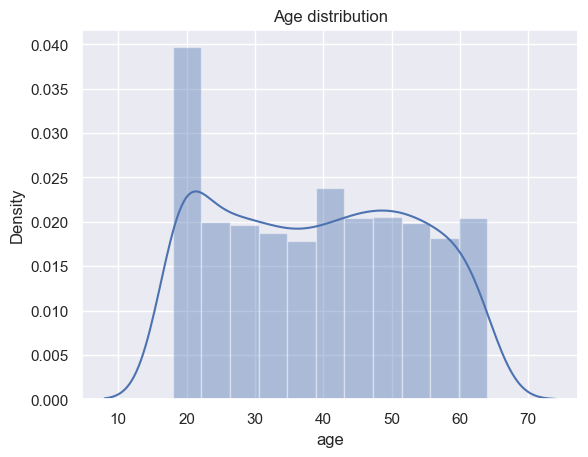

In [15]:
#ditribution of age value
plt.Figure(figsize=(6,6))
sns.distplot(insurance_dataset['age'])
plt.title('Age distribution')
plt.show()

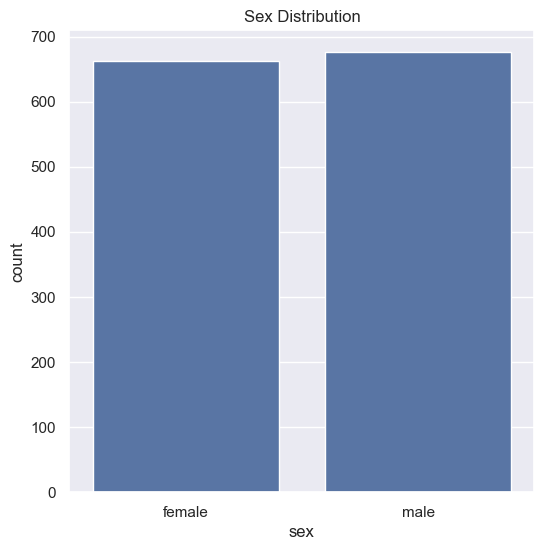

In [16]:
#Gender column
plt.figure(figsize=(6,6))
sns.countplot(x='sex',data =insurance_dataset)
plt.title('Sex Distribution')
plt.show()

In [14]:
insurance_dataset['sex'].value_counts()

sex
male      676
female    662
Name: count, dtype: int64

C:\Users\Sweta\AppData\Local\Temp\ipykernel_26812\1187924274.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(insurance_dataset['bmi'])


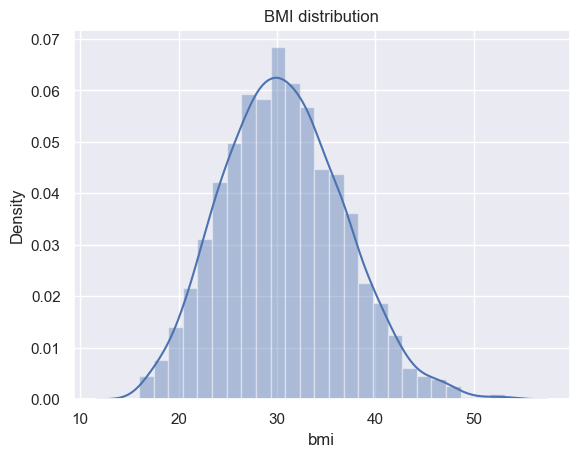

In [17]:
#bmi distribution
plt.Figure(figsize=(6,6))
sns.distplot(insurance_dataset['bmi'])
plt.title('BMI distribution')
plt.show()

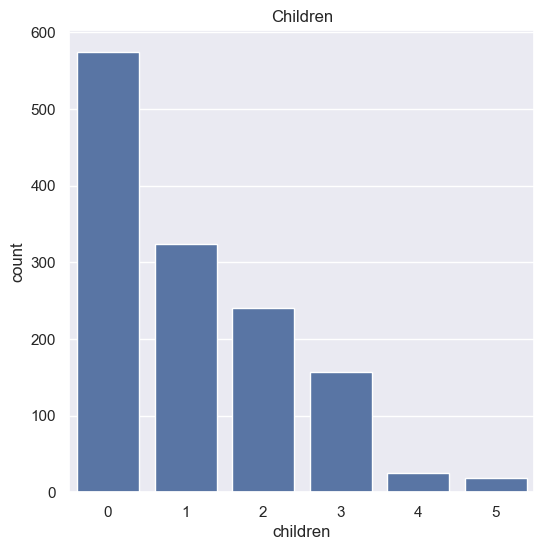

In [18]:
#children column
plt.figure(figsize=(6,6))
sns.countplot(x='children' , data = insurance_dataset)
plt.title('Children')
plt.show()

In [19]:
insurance_dataset['children'].value_counts()

children
0    574
1    324
2    240
3    157
4     25
5     18
Name: count, dtype: int64

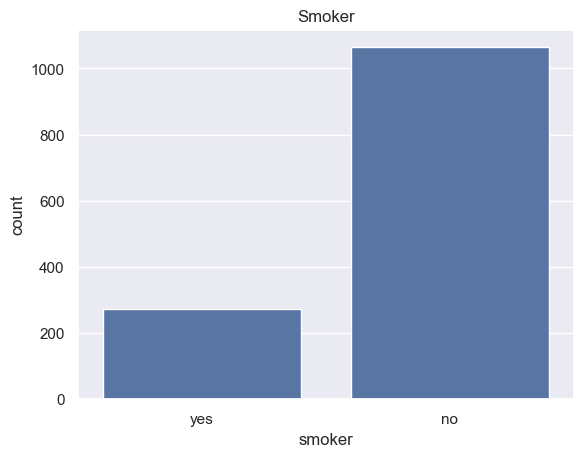

In [20]:
#Smoker column
plt.Figure(figsize=(6,6))
sns.countplot(x='smoker' , data = insurance_dataset)
plt.title('Smoker')
plt.show()


In [21]:
insurance_dataset['smoker'].value_counts()

smoker
no     1064
yes     274
Name: count, dtype: int64

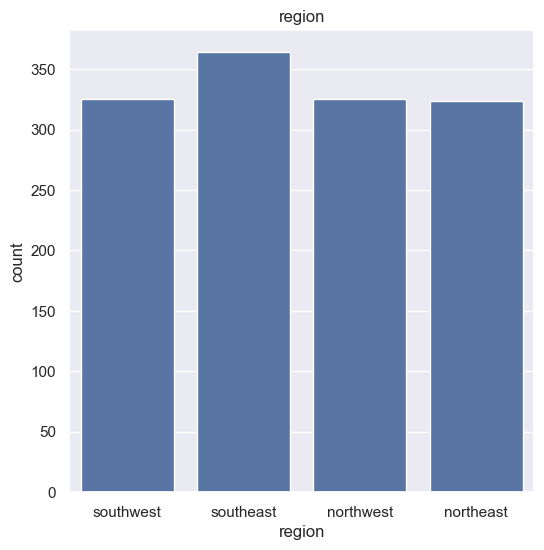

In [22]:
#region column
plt.figure(figsize=(6,6))
sns.countplot(x='region' , data = insurance_dataset)
plt.title('region')
plt.show()

In [23]:
insurance_dataset['region'].value_counts()

region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64

C:\Users\Sweta\AppData\Local\Temp\ipykernel_26812\2014996845.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(insurance_dataset['charges'])


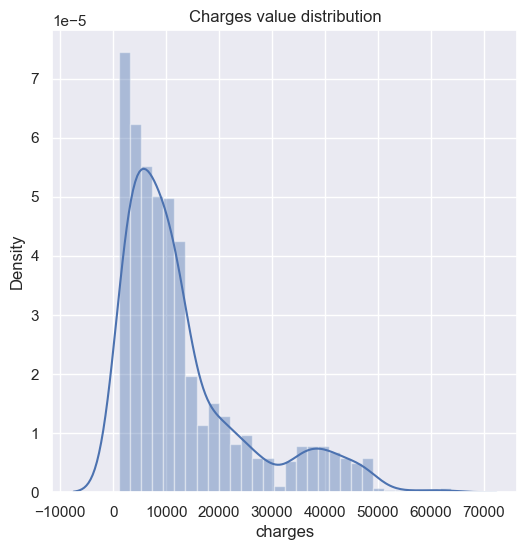

In [24]:
#charges value distribution 
plt.figure(figsize=(6,6))
sns.distplot(insurance_dataset['charges'])
plt.title('Charges value distribution')
plt.show()

## 4. Data Preprocessing

To use machine learning models, I convert categorical features into numeric form:

- `sex`: male → 0, female → 1  
- `smoker`: yes → 0, no → 1  
- `region`: southeast → 0, southwest → 1, northeast → 2, northwest → 3  



In [35]:
#encoding 'sex' column
insurance_dataset.replace({'sex':{'male':0, 'female': 1}}, inplace=True)

#encoding 'smoker' column
insurance_dataset.replace({'smoker':{'yes':1, 'no': 0}}, inplace=True)

#encoding 'region' column
insurance_dataset.replace({'region':{'southeast':0, 'southwest':1, 'northeast':2 ,'northwest':3 }}, inplace=True)

C:\Users\Sweta\AppData\Local\Temp\ipykernel_26812\3124829630.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  insurance_dataset.replace({'sex':{'male':0, 'female': 1}}, inplace=True)
C:\Users\Sweta\AppData\Local\Temp\ipykernel_26812\3124829630.py:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  insurance_dataset.replace({'smoker':{'yes':1, 'no': 0}}, inplace=True)
C:\Users\Sweta\AppData\Local\Temp\ipykernel_26812\3124829630.py:8: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future vers

Splitting the features and charges

In [26]:
X = insurance_dataset.drop(columns='charges', axis = 1)
Y = insurance_dataset['charges']
print(X)
print(Y)

      age  sex     bmi  children  smoker  region
0      19    1  27.900         0       0       1
1      18    0  33.770         1       1       0
2      28    0  33.000         3       1       0
3      33    0  22.705         0       1       3
4      32    0  28.880         0       1       3
...   ...  ...     ...       ...     ...     ...
1333   50    0  30.970         3       1       3
1334   18    1  31.920         0       1       2
1335   18    1  36.850         0       1       0
1336   21    1  25.800         0       1       1
1337   61    1  29.070         0       0       3

[1338 rows x 6 columns]
0       16884.92400
1        1725.55230
2        4449.46200
3       21984.47061
4        3866.85520
           ...     
1333    10600.54830
1334     2205.98080
1335     1629.83350
1336     2007.94500
1337    29141.36030
Name: charges, Length: 1338, dtype: float64


## 5. Train-Test Split

I split the data into:
- 80% training data  
- 20% testing data  


In [27]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state= 2)

In [28]:
print(X.shape, X_train.shape, X_test.shape)

(1338, 6) (1070, 6) (268, 6)


## 6. Model Training - Linear Regression


In [29]:
#LinearRegression
regressor = LinearRegression()
regressor.fit(X_train, Y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


## 7. Model Evaluation


In [30]:
# Predictions on training data
training_data_prediction = regressor.predict(X_train)

# Predictions on test data
test_data_prediction = regressor.predict(X_test)

# R² score
r2_train = metrics.r2_score(Y_train, training_data_prediction)
r2_test = metrics.r2_score(Y_test, test_data_prediction)

print("Training R² Score:", r2_train)
print("Testing R² Score:", r2_test)

# MAE & RMSE (extra, looks very professional)
mae = metrics.mean_absolute_error(Y_test, test_data_prediction)
rmse = np.sqrt(metrics.mean_squared_error(Y_test, test_data_prediction))

print("\nMean Absolute Error (Test):", mae)
print("Root Mean Squared Error (Test):", rmse)


Training R² Score: 0.751505643411174
Testing R² Score: 0.7447273869684077

Mean Absolute Error (Test): 4267.213826730735
Root Mean Squared Error (Test): 6191.690842285234


## 8. Feature Importance (Linear Regression Coefficients)


In [38]:
coeff_df = pd.DataFrame(regressor.coef_, X.columns, columns=['Coefficient'])
coeff_df


,Coefficient
age,251.405122
sex,26.117160
bmi,330.646372
children,580.274383
smoker,-23928.101711
region,212.222427


## 9. Building a Predictive System

In [32]:
input_data = (31, 1, 25.74, 0, 1, 0)
# age, sex, bmi, children, smoker, region

input_data_as_numpy_array = np.asarray(input_data)
input_data_reshaped = input_data_as_numpy_array.reshape(1,-1)

prediction = regressor.predict(input_data_reshaped)

print("Input Data:")
print(f"Age: {input_data[0]}")
print(f"Sex (1=female, 0=male): {input_data[1]}")
print(f"BMI: {input_data[2]}")
print(f"Children: {input_data[3]}")
print(f"Smoker (1=yes, 0=no): {input_data[4]}")
print(f"Region (0–3): {input_data[5]}")

print("\n💰 Predicted Insurance Cost (USD):", round(prediction[0], 2))


Input Data:
Age: 31
Sex (1=female, 0=male): 1
BMI: 25.74
Children: 0
Smoker (1=yes, 0=no): 1
Region (0–3): 0

💰 Predicted Insurance Cost (USD): 3760.08


c:\Medical insurance  cost prediction\env\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
